# RelayBP Hyperparameter Tuning

This notebook is a refactor of https://github.com/trmue/relay/blob/main/examples/RotatedSurfaceCodeAnalysis.ipynb.

Two-phase workflow for tuning the RelayBP decoder:
1. **Phase 1** — Sweep `gamma0` to find the optimal MemBP memory strength
2. **Phase 2** — Optimize `gamma_dist_interval` using Nevergrad

In [1]:
%reload_ext autoreload
%autoreload 2
import os
from typing import Any

import matplotlib.pyplot as plt
import nevergrad as ng
import numpy as np
from qecdec.circuits import create_circuit_with_uniform_error_rate
from qecdec.decoders import (
    BPDecoder,
    MemBPDecoder,
    MWPMDecoder,
    RelayBPDecoder,
    UnionFindDecoder,
)
from qecdec.sinter_utils import QecdecSinterDecoder
import sinter

In [2]:
# List of gamma0 values to sweep
MEMBP_GAMMA0S: list[float] = np.linspace(0, 1, 21).tolist()

# Fixed parameters for RelayBPDecoder
RELAYBP_FIXED_PARAMS = {
    "num_relays": 16,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

# nevergrad optimization budget
NG_BUDGET = 100

# approximate MemBP-failing shots used for nevergrad optimization
NG_SHOTS = 1000

## Helper functions

In [3]:
def tune_relaybp(
    *, circuit_name: str, circuit_params: dict[str, Any], opt_error_rate: float
) -> tuple[float, tuple[float, float]]:
    print("#" * 10, "Creating circuit...", flush=True)
    opt_circuit = create_circuit_with_uniform_error_rate(
        circuit_name, opt_error_rate, **circuit_params, flush=True
    )

    def tune_gamma0() -> tuple[float, float]:
        print("#" * 10, "Generating tasks for gamma0 sweep...", flush=True)
        tasks: list[sinter.Task] = []
        custom_decoders: dict[str, sinter.Decoder] = {}

        for gamma0 in MEMBP_GAMMA0S:
            decoder = MemBPDecoder(
                opt_circuit.chkmat,
                opt_circuit.prior,
                gamma=gamma0,
                max_iter=RELAYBP_FIXED_PARAMS["pre_iter"],
            )
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                decoder, opt_circuit.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=opt_circuit.stim_circuit,
                    detector_error_model=opt_circuit.stim_dem,
                    decoder=custom_decoder_id,
                    json_metadata={"gamma0": gamma0},
                )
            )

        print("#" * 10, "Collecting gamma0 sweep stats...", flush=True)
        gamma0_sweep_stats = sinter.collect(
            num_workers=os.cpu_count() - 1,
            max_shots=10_000_000,
            max_errors=100,
            tasks=tasks,
            custom_decoders=custom_decoders,
            print_progress=False,
        )

        print("#" * 10, "Plotting gamma0 sweep results...", flush=True)
        fig, ax = plt.subplots()
        sinter.plot_error_rate(
            ax=ax,
            stats=gamma0_sweep_stats,
            x_func=lambda stat: stat.json_metadata["gamma0"],
        )
        ax.semilogy()
        ax.grid()
        ax.set_ylabel("LER (per shot)")
        ax.set_xlabel("gamma0")
        ax.set_title("gamma0 sweep")
        fig.show()

        return min(
            (stats.errors / stats.shots, stats.json_metadata["gamma0"])
            for stats in gamma0_sweep_stats
        )

    membp_ler_star, gamma0_star = tune_gamma0()
    print(
        f"Optimal gamma0: {gamma0_star:.2f}; LER: {membp_ler_star:.2e}",
        flush=True,
    )
    assert membp_ler_star > 0, "No MemBP failures found; cannot train RelayBP."

    ng_raw_shots = int(NG_SHOTS / membp_ler_star)

    def build_ng_training_data() -> tuple[np.ndarray, np.ndarray]:
        print("#" * 10, "Building training data...", flush=True)

        sampler = opt_circuit.stim_dem.compile_sampler()
        syndromes, observables, _ = sampler.sample(ng_raw_shots)
        syndromes, observables = (
            syndromes.astype(np.uint8),
            observables.astype(np.uint8),
        )

        # Only use samples that fail MemBP to train RelayBP
        membp = MemBPDecoder(
            opt_circuit.chkmat,
            opt_circuit.prior,
            gamma=gamma0_star,
            max_iter=RELAYBP_FIXED_PARAMS["pre_iter"],
        )
        ehat = membp.decode_batch(syndromes, parallel=True)
        predicted_observables = (ehat @ opt_circuit.obsmat.T) % 2
        mask = np.any(observables != predicted_observables, axis=1)
        print(
            f"Out of {ng_raw_shots} there are {np.sum(mask)} MemBP-failing shots to train with.",
            flush=True,
        )
        return syndromes[mask], observables[mask]

    syndromes, observables = build_ng_training_data()

    def cost_function(gdi_low: float, gdi_high: float) -> float:
        """Return the logical error rate for a given gamma_dist_interval."""
        print(f"Starting cost evaluation for {(gdi_low, gdi_high)}.")
        decoder = RelayBPDecoder(
            opt_circuit.chkmat,
            opt_circuit.prior,
            gamma0=gamma0_star,
            gamma_dist_interval=(gdi_low, gdi_high),
            **RELAYBP_FIXED_PARAMS,
        )
        ehat = decoder.decode_batch(syndromes, parallel=True)
        predicted_observables = (ehat @ opt_circuit.obsmat.T) % 2
        mask = np.any(observables != predicted_observables, axis=1)
        errors = int(np.sum(mask))
        return errors / ng_raw_shots

    def tune_gamma_dist_interval() -> tuple[float, float]:
        print("#" * 10, "Tuning gamma_dist_interval...")

        def ensure_gamma_interval_ordered(vals):
            param_dict = vals[1]
            return param_dict["gdi_low"] < param_dict["gdi_high"]

        params = ng.p.Instrumentation(
            gdi_low=ng.p.Scalar(init=-0.25, lower=-0.5, upper=0.5),
            gdi_high=ng.p.Scalar(init=0.75, lower=0.0, upper=1.0),
        )
        params.register_cheap_constraint(ensure_gamma_interval_ordered)

        optimizer = ng.optimizers.TwoPointsDE(parametrization=params, budget=NG_BUDGET)
        optimizer.register_callback("tell", ng.callbacks.ProgressBar())

        recommendation = optimizer.minimize(cost_function, verbosity=2)

        return (
            recommendation[1]["gdi_low"].value,
            recommendation[1]["gdi_high"].value,
        )

    gdi_star = tune_gamma_dist_interval()
    print(
        f"Summary: Optimized gamma0: {gamma0_star}, gamma_dist_interval: {gdi_star}, LER: {cost_function(*gdi_star):.2e}",
        flush=True,
    )

    return gamma0_star, gdi_star


In [4]:
def compare_relaybp_with_other_decoders(
    *,
    circuit_name: str,
    circuit_params: dict[str, Any],
    error_rates: list[float],
    gamma0_star: float,
    gdi_star: tuple[float, float],
    decoder_names: list[str],
):
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}

    for p in error_rates:
        circuit = create_circuit_with_uniform_error_rate(
            circuit_name, p, **circuit_params
        )

        for decoder_name in decoder_names:
            if decoder_name == "BP":
                bp = BPDecoder(
                    circuit.chkmat,
                    circuit.prior,
                    max_iter=RELAYBP_FIXED_PARAMS["pre_iter"],
                )
                bp_id = f"custom_decoder_{len(custom_decoders)}"
                custom_decoders[bp_id] = QecdecSinterDecoder(bp, circuit.obsmat)
                tasks.append(
                    sinter.Task(
                        circuit=circuit.stim_circuit,
                        detector_error_model=circuit.stim_dem,
                        decoder=bp_id,
                        json_metadata={"p": p, "decoder": "BP"},
                    )
                )
            elif decoder_name == "MemBP":
                membp = MemBPDecoder(
                    circuit.chkmat,
                    circuit.prior,
                    gamma=gamma0_star,
                    max_iter=RELAYBP_FIXED_PARAMS["pre_iter"],
                )
                membp_id = f"custom_decoder_{len(custom_decoders)}"
                custom_decoders[membp_id] = QecdecSinterDecoder(membp, circuit.obsmat)
                tasks.append(
                    sinter.Task(
                        circuit=circuit.stim_circuit,
                        detector_error_model=circuit.stim_dem,
                        decoder=membp_id,
                        json_metadata={"p": p, "decoder": "MemBP"},
                    )
                )
            elif decoder_name == "RelayBP":
                relaybp = RelayBPDecoder(
                    circuit.chkmat,
                    circuit.prior,
                    gamma0=gamma0_star,
                    gamma_dist_interval=gdi_star,
                    **RELAYBP_FIXED_PARAMS,
                )
                relaybp_id = f"custom_decoder_{len(custom_decoders)}"
                custom_decoders[relaybp_id] = QecdecSinterDecoder(
                    relaybp, circuit.obsmat
                )
                tasks.append(
                    sinter.Task(
                        circuit=circuit.stim_circuit,
                        detector_error_model=circuit.stim_dem,
                        decoder=relaybp_id,
                        json_metadata={"p": p, "decoder": "RelayBP"},
                    )
                )
            elif decoder_name == "MWPM":
                mwpm = MWPMDecoder(circuit.chkmat, circuit.prior)
                mwpm_id = f"custom_decoder_{len(custom_decoders)}"
                custom_decoders[mwpm_id] = QecdecSinterDecoder(mwpm, circuit.obsmat)
                tasks.append(
                    sinter.Task(
                        circuit=circuit.stim_circuit,
                        detector_error_model=circuit.stim_dem,
                        decoder=mwpm_id,
                        json_metadata={"p": p, "decoder": "MWPM"},
                    )
                )
            elif decoder_name == "UnionFind":
                uf = UnionFindDecoder(circuit.chkmat, circuit.prior)
                uf_id = f"custom_decoder_{len(custom_decoders)}"
                custom_decoders[uf_id] = QecdecSinterDecoder(uf, circuit.obsmat)
                tasks.append(
                    sinter.Task(
                        circuit=circuit.stim_circuit,
                        detector_error_model=circuit.stim_dem,
                        decoder=uf_id,
                        json_metadata={"p": p, "decoder": "UnionFind"},
                    )
                )
            else:
                raise NotImplementedError

    all_stats = sinter.collect(
        num_workers=os.cpu_count() - 1,
        max_shots=10_000_000,
        max_errors=100,
        tasks=tasks,
        custom_decoders=custom_decoders,
        print_progress=True,
    )

    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=all_stats,
        group_func=lambda stat: f"{stat.json_metadata['decoder']}",
        x_func=lambda stat: stat.json_metadata["p"],
    )
    ax.loglog()
    ax.grid()
    ax.set_ylabel("LER (per shot)")
    ax.set_xlabel("PER")
    ax.set_title(f"{circuit_name}")
    ax.legend()

    fig.show()


## RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11, error_rate=0.001

In [7]:
circuit_name="RotatedSurfaceCode_Circuit"
circuit_params={"basis": "Z", "d": 11, "rounds": 11}

########## Creating circuit...
########## Generating tasks for gamma0 sweep...
########## Collecting gamma0 sweep stats...


########## Plotting gamma0 sweep results...
Optimal gamma0: 0.55; LER: 1.24e-03
########## Building training data...
Out of 808_894 there are 1_130 MemBP-failing shots to train with.
########## Tuning gamma_dist_interval...
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.29561057559244086, 0.7756839711224611).


0it [00:00, ?it/s]

Updating fitness with value 3.21426540436695e-05
99 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 3.21426540436695e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.29561057559244086, 'gdi_high': 0.7756839711224611})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.32477818489146015, 0.6230674118322943).


  2%|▏         | 2/100 [00:00<00:33,  2.90it/s]

...

Updating fitness with value 3.21426540436695e-05
2 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 1.3598815172321713e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.34811187475028277, 'gdi_high': 0.9479318039999579})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.3621902446821213, 0.8370107529072366).


 99%|█████████▉| 99/100 [01:12<00:00,  1.47it/s]

Updating fitness with value 2.9670142194156466e-05
1 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 1.3598815172321713e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.34811187475028277, 'gdi_high': 0.9479318039999579})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.2675851948905391, 0.8945502030142705).


100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


Updating fitness with value 2.3488862570373868e-05
0 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 1.3598815172321713e-05, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.34811187475028277, 'gdi_high': 0.9479318039999579})>
Starting cost evaluation for (-0.34811187475028277, 0.9479318039999579).
Summary: Optimized gamma0: 0.55, gamma_dist_interval: (-0.34811187475028277, 0.9479318039999579), LER: 1.61e-05


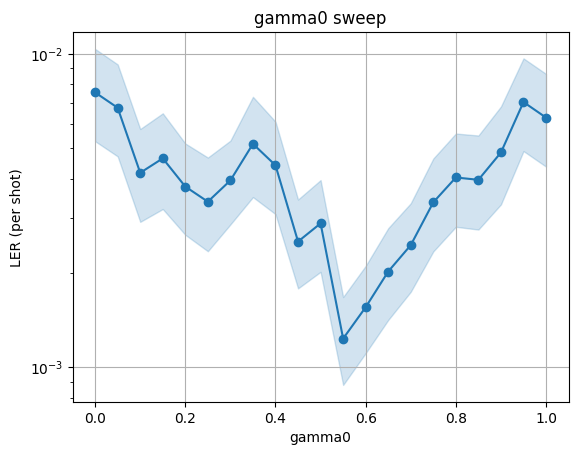

In [ ]:
gamma0_star, gdi_star = tune_relaybp(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    opt_error_rate=0.001,
)

Starting 31 workers...
25 tasks left:
  workers           decoder eta shots_left errors_left json_metadata            
        1  custom_decoder_0   ?   10000000         100 p=0.001,decoder=BP       
        1  custom_decoder_1   ?   10000000         100 p=0.001,decoder=MemBP    
        1  custom_decoder_2   ?   10000000         100 p=0.001,decoder=RelayBP  
        1  custom_decoder_3 68m    9999999         100 p=0.001,decoder=UnionFind
        1  custom_decoder_4   ?   10000000         100 p=0.001,decoder=MWPM     
        1  custom_decoder_5   ?   10000000         100 p=0.002,decoder=BP       
        1  custom_decoder_6   ?   10000000         100 p=0.002,decoder=MemBP    
        1  custom_decoder_7   ?   10000000         100 p=0.002,decoder=RelayBP  
        1  custom_decoder_8   ?   10000000         100 p=0.002,decoder=UnionFind
        1  custom_decoder_9   ?   10000000         100 p=0.002,decoder=MWPM     
        1 custom_decoder_10   ?   10000000         100 p=0.003,decoder=

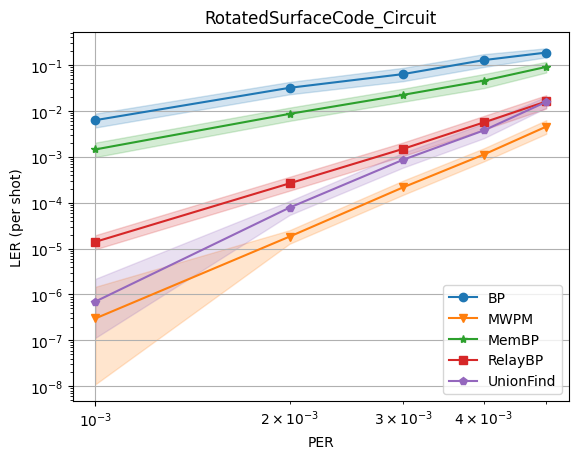

In [8]:
compare_relaybp_with_other_decoders(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    error_rates=[0.001, 0.002, 0.003, 0.004, 0.005],
    gamma0_star=gamma0_star,
    gdi_star=gdi_star,
    decoder_names=["BP", "MemBP", "RelayBP", "UnionFind", "MWPM"],
)

## RotatedSurfaceCode_Phenom, basis=Z, d=11, rounds=11, error_rate=0.005

In [5]:
circuit_name="RotatedSurfaceCode_Phenom"
circuit_params={"basis": "Z", "d": 11, "rounds": 11}

########## Creating circuit...
########## Generating tasks for gamma0 sweep...


########## Collecting gamma0 sweep stats...
########## Plotting gamma0 sweep results...
Optimal gamma0: 0.65; LER: 6.56e-03
########## Building training data...
Out of 152522 there are 1099 MemBP-failing shots to train with.
########## Tuning gamma_dist_interval...
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.09377556520786479, 0.833015214646784).


0it [00:00, ?it/s]

Updating fitness with value 0.00016391078008418458
99 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 0.00016391078008418458, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.09377556520786479, 'gdi_high': 0.833015214646784})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.3595051708394347, 0.7297816342658738).


  2%|▏         | 2/100 [00:00<00:19,  5.00it/s]

...

Updating fitness with value 1.966929361010215e-05
2 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 6.556431203367383e-06, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2241259276391633, 'gdi_high': 0.5608805426310253})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.2509645686088039, 0.41378201769797945).


 99%|█████████▉| 99/100 [00:47<00:00,  3.31it/s]

Updating fitness with value 3.278215601683691e-05
1 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 6.556431203367383e-06, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2241259276391633, 'gdi_high': 0.5608805426310253})>
Launching 1 jobs with new suggestions
Starting cost evaluation for (-0.21506472735370846, 0.8847197272739385).


100%|██████████| 100/100 [00:47<00:00,  2.10it/s]


Updating fitness with value 3.93385872202043e-05
0 remaining budget and 0 running jobs
Current pessimistic best is: MultiValue<mean: 6.556431203367383e-06, count: 1, parameter: Instrumentation(Tuple(),Dict(gdi_high=Scalar{Cl(0,1,b)}[sigma=Scalar{exp=2.03}],gdi_low=Scalar{Cl(-0.5,0.5,b)}[sigma=Scalar{exp=2.03}])):((), {'gdi_low': -0.2241259276391633, 'gdi_high': 0.5608805426310253})>
Starting cost evaluation for (-0.2241259276391633, 0.5608805426310253).
Summary: Optimized gamma0: 0.65, gamma_dist_interval: (-0.2241259276391633, 0.5608805426310253), LER: 1.97e-05


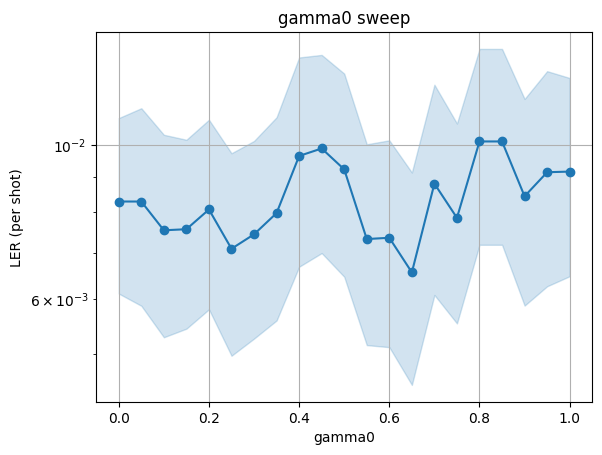

In [6]:
gamma0_star, gdi_star = tune_relaybp(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    opt_error_rate=0.005,
)

Starting 31 workers...
25 tasks left:
  workers           decoder eta shots_left errors_left json_metadata            
        1  custom_decoder_0   ?   10000000         100 p=0.005,decoder=BP       
        1  custom_decoder_1   ?   10000000         100 p=0.005,decoder=MemBP    
        1  custom_decoder_2 70m    9999999         100 p=0.005,decoder=RelayBP  
        1  custom_decoder_3   ?   10000000         100 p=0.005,decoder=UnionFind
        1  custom_decoder_4   ?   10000000         100 p=0.005,decoder=MWPM     
        1  custom_decoder_5   ?   10000000         100 p=0.006,decoder=BP       
        1  custom_decoder_6   ?   10000000         100 p=0.006,decoder=MemBP    
        1  custom_decoder_7   ?   10000000         100 p=0.006,decoder=RelayBP  
        1  custom_decoder_8   ?   10000000         100 p=0.006,decoder=UnionFind
        1  custom_decoder_9   ?   10000000         100 p=0.006,decoder=MWPM     
        1 custom_decoder_10   ?   10000000         100 p=0.007,decoder=

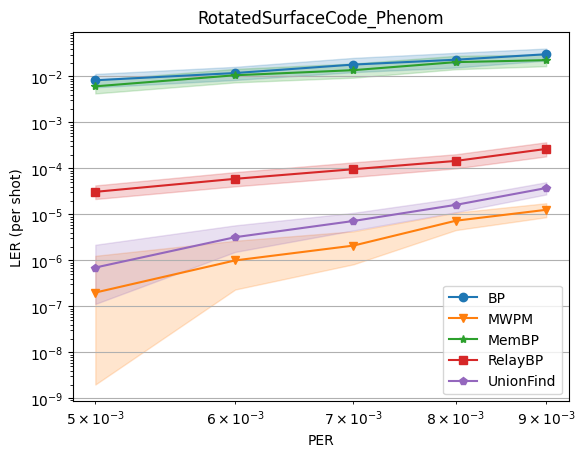

In [7]:
compare_relaybp_with_other_decoders(
    circuit_name=circuit_name,
    circuit_params=circuit_params,
    error_rates=[0.005, 0.006, 0.007, 0.008, 0.009],
    gamma0_star=gamma0_star,
    gdi_star=gdi_star,
    decoder_names=["BP", "MemBP", "RelayBP", "UnionFind", "MWPM"],
)